<a href="https://colab.research.google.com/github/thechiragbatra/customer-churn-mlops/blob/main/1.eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("✅ Shape:", df.shape)
print("\n✅ Columns:", df.columns.tolist())
print("\n✅ Churn distribution:\n", df['Churn'].value_counts(normalize=True))
print("\n✅ Data types:\n", df.dtypes)
print("\n✅ Missing values:\n", df.isnull().sum())

✅ Shape: (7043, 21)

✅ Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

✅ Churn distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

✅ Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Tot

In [9]:
# ── CELL 2: Data Cleaning ──────────────────────────────
# Fix TotalCharges: convert to numeric (empty strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN appeared
print("NaN in TotalCharges:", df['TotalCharges'].isnull().sum())

# Drop those rows (only ~11 rows)
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts:\n", df['Churn'].value_counts())

# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)

print("\n✅ Data cleaned and ready!")


NaN in TotalCharges: 11
Shape after cleaning: (7032, 21)
Churn value counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64

✅ Data cleaned and ready!


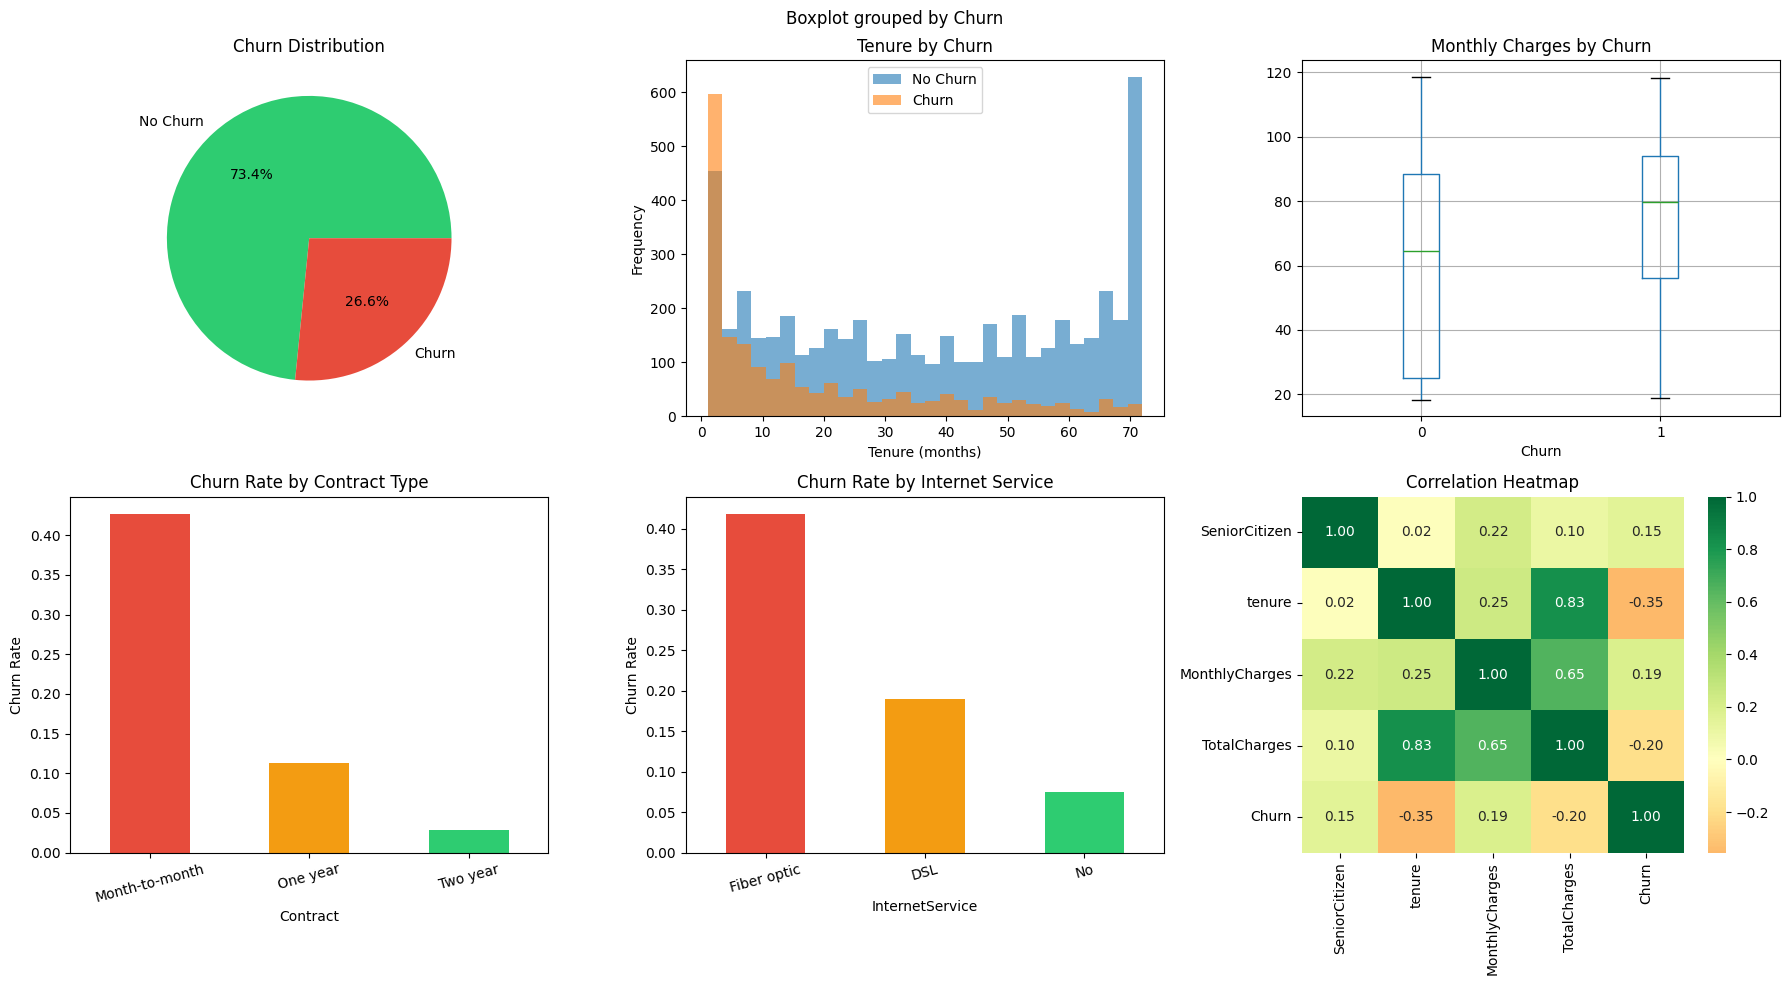

✅ EDA plots saved!


In [10]:
# ── CELL 3: EDA Visualizations ─────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn EDA', fontsize=16, fontweight='bold')

# 1. Churn distribution
axes[0,0].pie(df['Churn'].value_counts(), labels=['No Churn','Churn'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Churn Distribution')

# 2. Tenure vs Churn
df.groupby('Churn')['tenure'].plot(kind='hist', alpha=0.6, bins=30,
                                    ax=axes[0,1], legend=True)
axes[0,1].set_title('Tenure by Churn')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].legend(['No Churn', 'Churn'])

# 3. Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0,2])
axes[0,2].set_title('Monthly Charges by Churn')
axes[0,2].set_xlabel('Churn')

# 4. Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[1,0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,0].set_title('Churn Rate by Contract Type')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Internet Service vs Churn
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
internet_churn.plot(kind='bar', ax=axes[1,1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].tick_params(axis='x', rotation=15)

# 6. Correlation heatmap (numeric only)
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,2], center=0)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

In [11]:
# ── CELL 4: Feature Engineering ────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Encode all categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print("\nFeature shape:", X.shape)
print("Class distribution:\n", y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\n✅ Train size:", X_train.shape)
print("✅ Test size:", X_test.shape)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Feature shape: (7032, 19)
Class distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64

✅ Train size: (5625, 19)
✅ Test size: (1407, 19)


In [12]:
!pip install mlflow xgboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [13]:
# ── CELL 5: SMOTE + XGBoost Training ───────────────────
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import mlflow
import mlflow.xgboost

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE - Class distribution:", dict(zip(*np.unique(y_train_sm, return_counts=True))))

# Train XGBoost
mlflow.set_experiment("churn-prediction")

with mlflow.start_run():
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )

    model.fit(X_train_sm, y_train_sm)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_prob)

    # Log to MLflow
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("auc_roc", auc)
    mlflow.xgboost.log_model(model, "xgboost_churn_model")

    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"✅ AUC-ROC Score: {auc:.4f}")
    print(f"✅ Model logged to MLflow!")

After SMOTE - Class distribution: {np.int64(0): np.int64(4130), np.int64(1): np.int64(4130)}


2026/05/23 18:35:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/23 18:35:16 INFO mlflow.store.db.utils: Updating database tables
2026/05/23 18:35:22 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/23 18:35:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.54      0.61      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.76      0.76      1407

✅ AUC-ROC Score: 0.8186
✅ Model logged to MLflow!


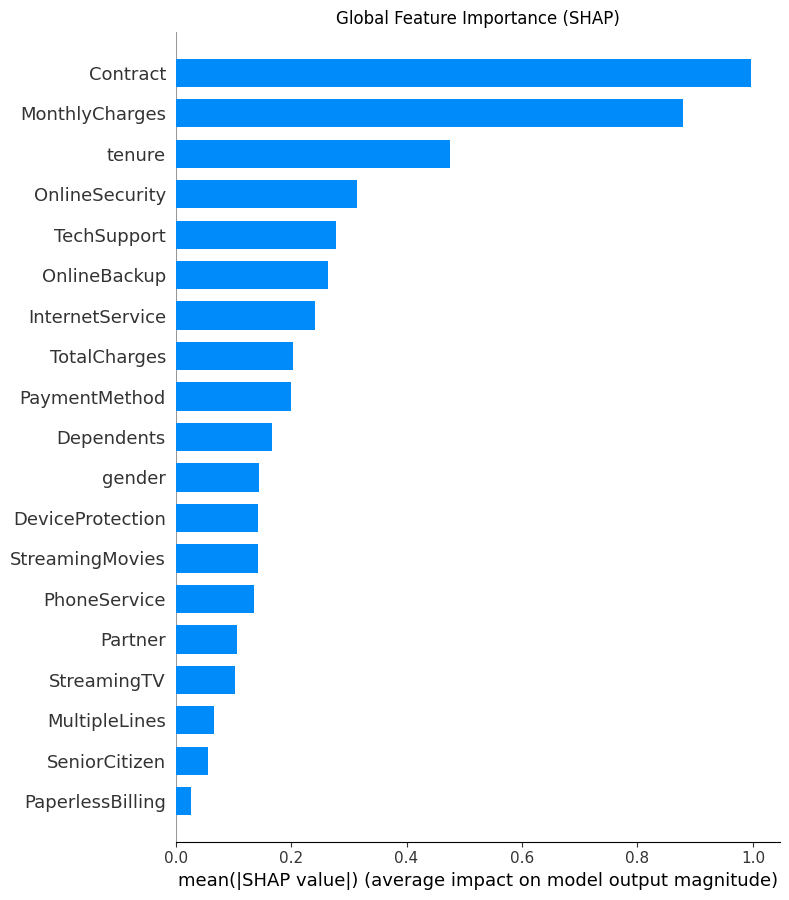

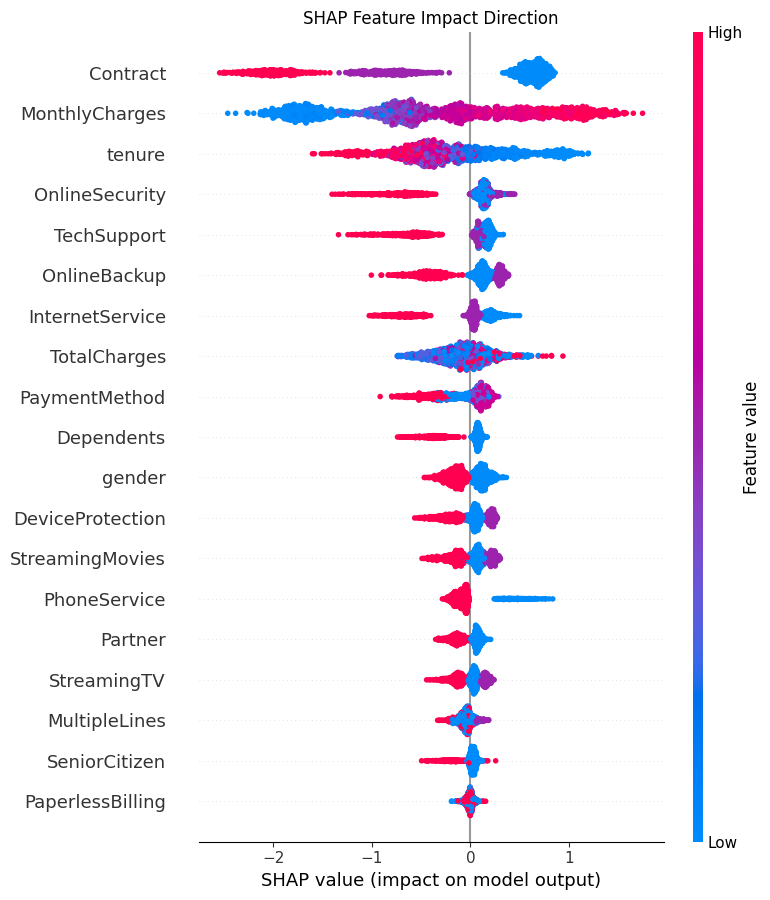


🔍 Top reasons this customer will churn:
  MonthlyCharges: ↓ decreases churn probability (SHAP=-1.710)
  InternetService: ↓ decreases churn probability (SHAP=-0.867)
  Contract: ↑ increases churn probability (SHAP=0.612)
  PaymentMethod: ↓ decreases churn probability (SHAP=-0.562)
  TotalCharges: ↓ decreases churn probability (SHAP=-0.493)

✅ SHAP explainability done!


In [14]:
# ── CELL 6: SHAP Explainability ────────────────────────
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — SHAP beeswarm (shows direction of impact)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact Direction")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-customer explanation (first churner in test set)
churner_idx = y_test[y_test == 1].index[0]
churner_pos = X_test.index.get_loc(churner_idx)

print("\n🔍 Top reasons this customer will churn:")
feature_shap = dict(zip(X_test.columns, shap_values[churner_pos]))
top_reasons = sorted(feature_shap.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
for feat, val in top_reasons:
    direction = "↑ increases" if val > 0 else "↓ decreases"
    print(f"  {feat}: {direction} churn probability (SHAP={val:.3f})")

print("\n✅ SHAP explainability done!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              Model  AUC-ROC  F1 (Churn)  Precision  Recall
            XGBoost   0.8186      0.5729     0.5446  0.6043
           LightGBM   0.8119      0.5658     0.5522  0.5802
Logistic Regression   0.8086      0.5918     0.5067  0.7112
      Random Forest   0.8082      0.5673     0.5550  0.5802


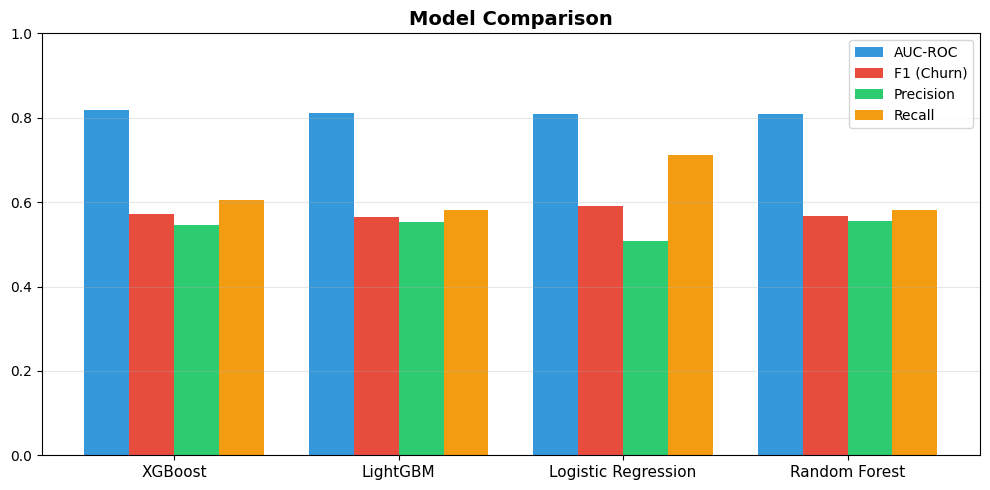


✅ Model comparison done!


In [15]:
# ── CELL: Model Comparison ─────────────────────────────
!pip install lightgbm -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                         random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":      name,
        "AUC-ROC":    round(roc_auc_score(y_test, y_prob), 4),
        "F1 (Churn)": round(f1_score(y_test, y_pred), 4),
        "Precision":  round(precision_score(y_test, y_pred), 4),
        "Recall":     round(recall_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.2

ax.bar([i - 0.3 for i in x], results_df['AUC-ROC'],    width, label='AUC-ROC',    color='#3498db')
ax.bar([i - 0.1 for i in x], results_df['F1 (Churn)'], width, label='F1 (Churn)', color='#e74c3c')
ax.bar([i + 0.1 for i in x], results_df['Precision'],  width, label='Precision',  color='#2ecc71')
ax.bar([i + 0.3 for i in x], results_df['Recall'],     width, label='Recall',     color='#f39c12')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model comparison done!")